In [1]:
# Cell 1 — Imports & Path Setup
import os
import torch
import torchaudio
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from bidi.algorithm import get_display
import pdfplumber

# Project paths
BASE_DIR  = Path("../")
RAW_DIR   = BASE_DIR / "data/raw/archive"
AUDIO_DIR = RAW_DIR / "files"
PDF_PATH  = RAW_DIR / "listofwords.pdf"

print("✅ Imports successful")
print(f"Audio dir exists : {AUDIO_DIR.exists()}")
print(f"PDF exists       : {PDF_PATH.exists()}")

✅ Imports successful
Audio dir exists : True
PDF exists       : True


In [2]:
words = {}
with pdfplumber.open(PDF_PATH) as pdf:
    for page in pdf.pages:
        text = page.extract_text()
        if not text:
            continue
        for line in text.split('\n'):
            line = line.strip()
            if not line:
                continue
            fixed = get_display(line)
            # Extract Urdu number and word
            parts = fixed.split()
            if len(parts) >= 2:
                num_str = parts[0]
                word = ' '.join(parts[1:])
                # Convert Urdu/Arabic numerals to int
                urdu_to_eng = str.maketrans('۰۱۲۳۴۵۶۷۸۹', '0123456789')
                num_str = num_str.translate(urdu_to_eng)
                try:
                    num = int(num_str)
                    words[num] = word
                except:
                    continue

print(f"✅ Total words extracted: {len(words)}")
print("\nSample mappings:")
for i in [1, 2, 3, 4, 5]:
    print(f"  Word {i:03d} → {words.get(i, 'N/A')}")

✅ Total words extracted: 205

Sample mappings:
  Word 001 → رفص
  Word 002 → ا ی
  Word 003 → دو
  Word 004 → نیت
  Word 005 → اچر


In [3]:
records = []
for speaker_dir in sorted(AUDIO_DIR.iterdir()):
    if not speaker_dir.is_dir():
        continue
    speaker = speaker_dir.name  # e.g. AAMNG1
    gender  = 'Male' if speaker[2] == 'M' else 'Female'
    native  = 'Native' if speaker[3] == 'Y' else 'Non-Native'
    group   = speaker[4:]  # e.g. NG1

    for wav_file in sorted(speaker_dir.glob("*.wav")):
        word_num = int(wav_file.stem[-3:])  # last 3 digits
        word     = words.get(word_num, '')
        records.append({
            'file_path' : str(wav_file),
            'speaker'   : speaker,
            'gender'    : gender,
            'native'    : native,
            'group'     : group,
            'word_num'  : word_num,
            'word'      : word
        })

df = pd.DataFrame(records)
print(f"✅ Total audio files found: {len(df)}")
print(f"   Speakers               : {df['speaker'].nunique()}")
print(f"   Unique words           : {df['word_num'].nunique()}")
print(f"\nSample rows:")
print(df.head(10))

✅ Total audio files found: 2500
   Speakers               : 10
   Unique words           : 250

Sample rows:
                                        file_path speaker gender      native  \
0  ..\data\raw\archive\files\AAMNG1\AAMNG1001.wav  AAMNG1   Male  Non-Native   
1  ..\data\raw\archive\files\AAMNG1\AAMNG1002.wav  AAMNG1   Male  Non-Native   
2  ..\data\raw\archive\files\AAMNG1\AAMNG1003.wav  AAMNG1   Male  Non-Native   
3  ..\data\raw\archive\files\AAMNG1\AAMNG1004.wav  AAMNG1   Male  Non-Native   
4  ..\data\raw\archive\files\AAMNG1\AAMNG1005.wav  AAMNG1   Male  Non-Native   
5  ..\data\raw\archive\files\AAMNG1\AAMNG1006.wav  AAMNG1   Male  Non-Native   
6  ..\data\raw\archive\files\AAMNG1\AAMNG1007.wav  AAMNG1   Male  Non-Native   
7  ..\data\raw\archive\files\AAMNG1\AAMNG1008.wav  AAMNG1   Male  Non-Native   
8  ..\data\raw\archive\files\AAMNG1\AAMNG1009.wav  AAMNG1   Male  Non-Native   
9  ..\data\raw\archive\files\AAMNG1\AAMNG1010.wav  AAMNG1   Male  Non-Native   

  group  w

In [4]:
print("=== Dataset Overview ===\n")
print(f"Total files   : {len(df)}")
print(f"Speakers      : {df['speaker'].nunique()}")
print(f"\nGender split:")
print(df['gender'].value_counts())
print(f"\nNative split:")
print(df['native'].value_counts())
print(f"\nAge group split:")
print(df['group'].value_counts())
print(f"\nMissing transcriptions: {(df['word'] == '').sum()}")

=== Dataset Overview ===

Total files   : 2500
Speakers      : 10

Gender split:
gender
Male      2000
Female     500
Name: count, dtype: int64

Native split:
native
Non-Native    1750
Native         750
Name: count, dtype: int64

Age group split:
group
G1    1500
G2    1000
Name: count, dtype: int64

Missing transcriptions: 460


File        : ..\data\raw\archive\files\AAMNG1\AAMNG1001.wav
Word        : رفص
Speaker     : AAMNG1
Sample rate : 16000 Hz
Duration    : 0.601 seconds
Shape       : torch.Size([1, 9610])


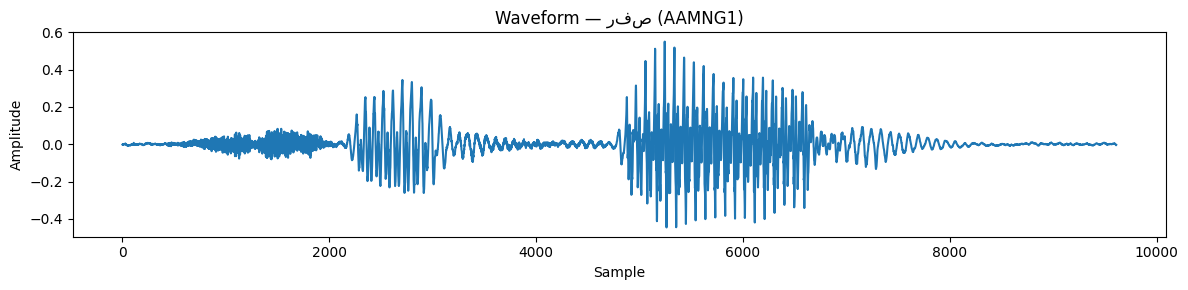

In [6]:
# Cell 5 — Load & Visualize One Audio File
import soundfile as sf

sample = df.iloc[0]
wav_path = sample['file_path']

# Load audio using soundfile directly (bypasses torchaudio backend issue)
audio_data, sample_rate = sf.read(wav_path)
waveform = torch.tensor(audio_data, dtype=torch.float32).unsqueeze(0)

print(f"File        : {wav_path}")
print(f"Word        : {sample['word']}")
print(f"Speaker     : {sample['speaker']}")
print(f"Sample rate : {sample_rate} Hz")
print(f"Duration    : {waveform.shape[1] / sample_rate:.3f} seconds")
print(f"Shape       : {waveform.shape}")

# Plot waveform
plt.figure(figsize=(12, 3))
plt.plot(waveform[0].numpy())
plt.title(f"Waveform — {sample['word']} ({sample['speaker']})")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

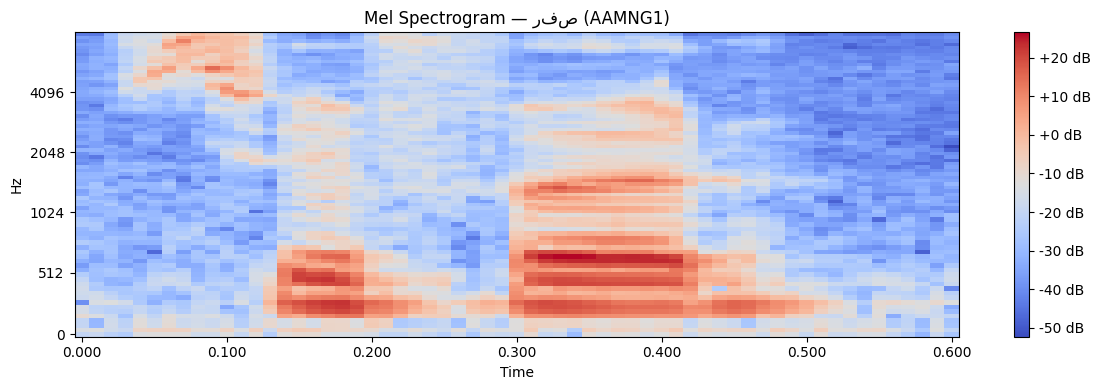

Mel Spectrogram shape: torch.Size([1, 80, 61])
(channels, mel_bins, time_frames)


In [7]:
# Cell 6 — Mel Spectrogram Visualization
import soundfile as sf

audio_data, sample_rate = sf.read(wav_path)
waveform = torch.tensor(audio_data, dtype=torch.float32).unsqueeze(0)

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=sample_rate,
    n_fft=400,
    hop_length=160,
    n_mels=80
)

mel_spec    = mel_transform(waveform)
mel_spec_db = torchaudio.transforms.AmplitudeToDB()(mel_spec)

plt.figure(figsize=(12, 4))
librosa.display.specshow(
    mel_spec_db[0].numpy(),
    sr=sample_rate,
    hop_length=160,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar(format='%+2.0f dB')
plt.title(f"Mel Spectrogram — {sample['word']} ({sample['speaker']})")
plt.tight_layout()
plt.show()

print(f"Mel Spectrogram shape: {mel_spec.shape}")
print("(channels, mel_bins, time_frames)")

In [8]:
output_path = BASE_DIR / "data/processed/metadata.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"✅ Metadata saved to: {output_path}")
print(f"   Shape: {df.shape}")

✅ Metadata saved to: ..\data\processed\metadata.csv
   Shape: (2500, 7)
